In [ ]:
import pandas as pd
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
import os
from node2vec import Node2Vec

In [ ]:
DATA_PATH = "/Users/natallia/MIS/Lab1/" 
FILE_RATINGS = "u.data"
FILE_MOVIES = "u.item"
THRESHOLD = 20 

In [ ]:
print(f"\n---Чтение файлов из пути: {DATA_PATH} ---")

try:
    ratings_filepath = os.path.join(DATA_PATH, FILE_RATINGS)
    ratings = pd.read_csv(ratings_filepath, sep='\t',
                          names=["user_id", "movie_id", "rating", "unix_timestamp"])
    print(f"DataFrame 'ratings' (u.data) - загружено {len(ratings)} строк.")
except FileNotFoundError:
    print(f"Ошибка: Файл '{ratings_filepath}' не найден. Проверьте путь.")
    exit()

try:
    movies_filepath = os.path.join(DATA_PATH, FILE_MOVIES)
    movies = pd.read_csv(movies_filepath, sep="|",
                         usecols=[0, 1],
                         names=["movie_id", "title"],
                         encoding="latin-1")
    print(f"DataFrame 'movies' (u.item) - загружено {len(movies)} строк.")
except FileNotFoundError:
    print(f"Ошибка: Файл '{movies_filepath}' не найден. Проверьте путь.")
    exit()

ratings = ratings[ratings.rating >= 4]
print(f"\nОсталось {len(ratings)} 'понравившихся' рейтингов (rating >= 4).")


---Чтение файлов из пути: /Users/natallia/MIS/Lab1/ ---
DataFrame 'ratings' (u.data) - загружено 100000 строк.
DataFrame 'movies' (u.item) - загружено 1682 строк.

Осталось 55375 'понравившихся' рейтингов (rating >= 4).


In [ ]:
print("\n--- Построение графа ---")
pairs = defaultdict(int)

for _, group in ratings.groupby("user_id"):
    user_movies = list(group["movie_id"])
    for i in range(len(user_movies)):
        for j in range(i + 1, len(user_movies)):
            pair = tuple(sorted((user_movies[i], user_movies[j])))
            pairs[pair] += 1

G = nx.Graph()

for pair, score in pairs.items():
    if score >= THRESHOLD:
        G.add_edge(pair[0], pair[1], weight=score)

print(f"Общее количество узлов в графе: {G.number_of_nodes()}")
print(f"Общее количество рёбер в графе: {G.number_of_edges()}")
print(f"Использован порог веса ребра: >={THRESHOLD}")


--- 🧠 Построение графа ---
Общее количество узлов в графе: 563
Общее количество рёбер в графе: 35904
Использован порог веса ребра: >=20


In [ ]:
print("\n--- Обучение Node2Vec ---")
node2vec = Node2Vec(G, dimensions=64, walk_length=20,
                    num_walks=200, p=2, q=1, workers=4) 

model = node2vec.fit(window=10, min_count=1, batch_words=4)
print("Обучение Node2Vec завершено. Вектора фильмов созданы.")


--- 📊 Обучение Node2Vec ---


Generating walks (CPU: 4): 100%|██████████| 50/50 [00:06<00:00,  7.76it/s]


Обучение Node2Vec завершено. Вектора фильмов созданы.


In [ ]:
def recommend(movie_title):
    """
    Рекомендует 5 похожих фильмов, используя векторы из Node2Vec.
    Включает проверку наличия фильма в данных и в графе.
    """
    print("\n" + "=" * 50)
    print(f"Поиск рекомендаций для: '{movie_title}'")
    
    movie_data = movies[movies.title == movie_title]
    if movie_data.empty:
        print(f"Ошибка: Фильм '{movie_title}' отсутствует в наборе данных MovieLens 100k.")
        return

    movie_id = movie_data.movie_id.values[0]
    movie_id_str = str(movie_id)

    if movie_id not in G.nodes():
        print(f"'{movie_title}' найден (ID: {movie_id}), но не имеет достаточно связей (меньше {THRESHOLD}) для включения в граф и модель Node2Vec.")
        print("Попробуйте другой более популярный фильм.")
        return
        
    print(f"Топ-5 рекомендаций по схожести вкусов пользователей:")
    
    try:
        for id_tuple in model.wv.most_similar(movie_id_str, topn=5):
            recommended_movie_id = int(id_tuple[0])
            similarity_score = id_tuple[1]
            
            title = movies[movies.movie_id == recommended_movie_id].title.values[0]
            
            print(f'- {title}: {similarity_score:.4f}')
    except KeyError:
         print(f"Невозможно получить рекомендации. Узел ID {movie_id} не найден в модели Node2Vec.")

In [ ]:
recommend('Star Wars (1977)')

recommend('Titanic (1997)') 

recommend('Last Man Standing (1996)')


Поиск рекомендаций для: 'Star Wars (1977)'
✨ Топ-5 рекомендаций по схожести вкусов пользователей:
- Return of the Jedi (1983): 0.7316
- Silence of the Lambs, The (1991): 0.6289
- Raiders of the Lost Ark (1981): 0.5819
- Empire Strikes Back, The (1980): 0.5686
- Fargo (1996): 0.5176

Поиск рекомендаций для: 'Titanic (1997)'
✨ Топ-5 рекомендаций по схожести вкусов пользователей:
- Air Force One (1997): 0.7307
- L.A. Confidential (1997): 0.6907
- Contact (1997): 0.6592
- Good Will Hunting (1997): 0.6219
- Game, The (1997): 0.5573

Поиск рекомендаций для: 'Last Man Standing (1996)'
⚠️ Фильм 'Last Man Standing (1996)' найден (ID: 840), но не имеет достаточно связей (меньше 20) для включения в граф и модель Node2Vec.
Попробуйте другой более популярный фильм.



🎨 Визуализация подграфа для фильма: Star Wars (1977)


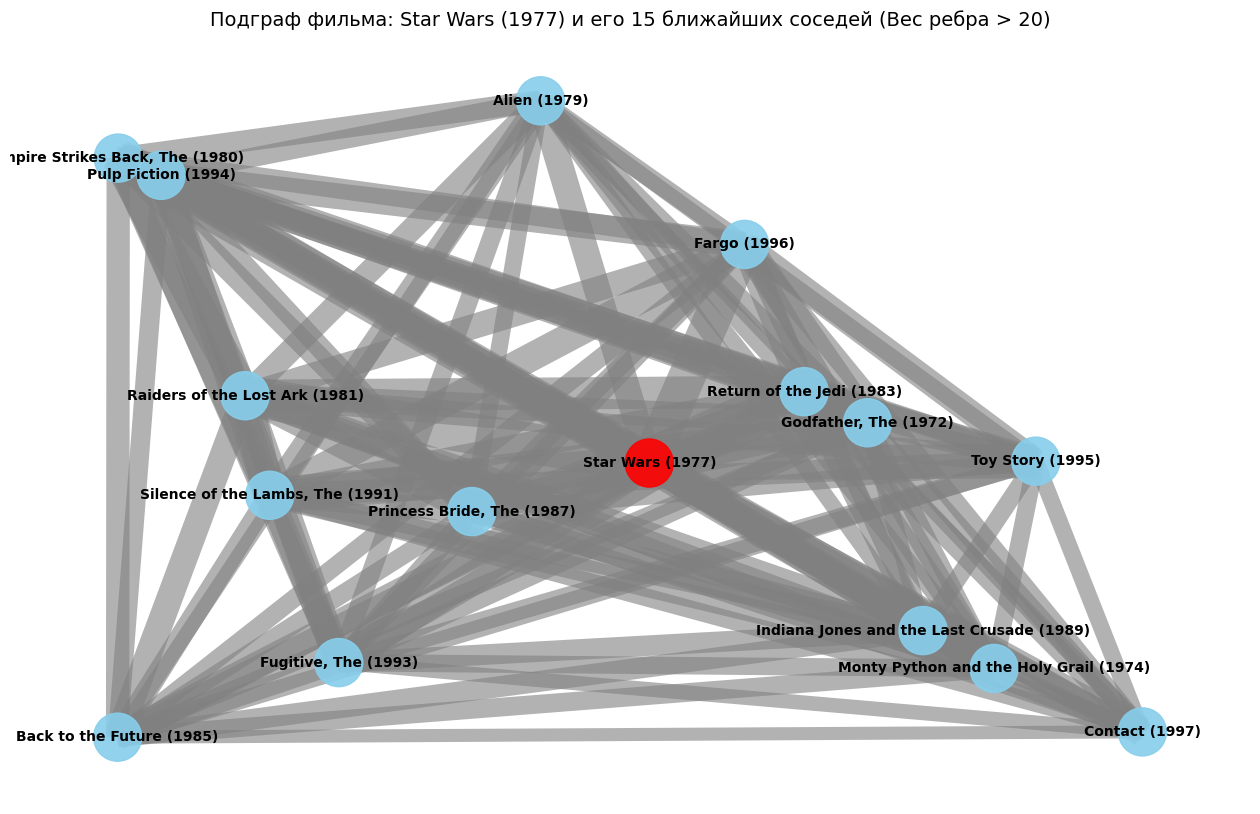

In [ ]:
def visualize_movie_subgraph(movie_title, G, movies, max_neighbors=15):
    """
    Визуализирует фильм и его ближайших соседей в графе G.
    Показывает, как фильмы связаны по совместным "лайкам" пользователей.
    """
    print("\n" + "=" * 50)
    print(f"Визуализация подграфа для фильма: {movie_title}")
    
    movie_data = movies[movies.title == movie_title]
    if movie_data.empty or movie_data.movie_id.values[0] not in G.nodes():
        print(f"Фильм '{movie_title}' не включен в граф G (нет достаточных связей).")
        return
        
    movie_id = movie_data.movie_id.values[0]

    edges = sorted(G.edges(movie_id, data=True), key=lambda x: x[2]['weight'], reverse=True)
    top_neighbors = [target for _, target, _ in edges[:max_neighbors]]
    subgraph_nodes = [movie_id] + top_neighbors
    H = G.subgraph(subgraph_nodes)
    
    labels = {node_id: movies[movies.movie_id == node_id].title.values[0]
              for node_id in H.nodes()}

    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(H, k=0.15, iterations=20, seed=42) 
    
    node_colors = ['red' if node == movie_id else 'skyblue' for node in H.nodes()]
    nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=1200, alpha=0.9)
    
    weights = [H[u][v]['weight'] * 0.1 for u, v in H.edges()]
    nx.draw_networkx_edges(H, pos, width=weights, edge_color='gray', alpha=0.6)
    
    nx.draw_networkx_labels(H, pos, labels, font_size=10, font_weight='bold')
    
    plt.title(f"Подграф фильма: {movie_title} и его {len(top_neighbors)} ближайших соседей (Вес ребра > {THRESHOLD})", fontsize=14)
    plt.axis('off')
    plt.show()

visualize_movie_subgraph('Star Wars (1977)', G, movies)